In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path
import sqlite3
#3/11 Ive decided to keep essential columns of the data variables for my prediction task. this include 
# FIRE_YEAR
# DISCOVERY_DATE
# CONT_DATE
# FIRE_SIZE
# STATE
# COUNTY
# LATITUDE
# LONGITUDE

# downloaded original dataset using kagglehub in cache
# use sqlite3 to operate on it
# convert julian time to YYYY-MM-DD



In [9]:
data_dir = Path(r"C:\Users\Frank\.cache\kagglehub\datasets\rtatman\188-million-us-wildfires\versions\2")
files = list(data_dir.glob("*"))
files

[WindowsPath('C:/Users/Frank/.cache/kagglehub/datasets/rtatman/188-million-us-wildfires/versions/2/FPA_FOD_20170508.sqlite')]

In [10]:
db_path = files[0]   # adjust if needed after you inspect files
conn = sqlite3.connect(db_path)

In [ ]:
pd.read_sql_query("PRAGMA table_info(Fires);", conn)

In [ ]:
preview = pd.read_sql_query("""
    SELECT *
    FROM Fires
    LIMIT 5
""", conn)

preview.T

In [ ]:
query = """
SELECT
    FIRE_YEAR,
    DISCOVERY_DATE,
    DISCOVERY_DOY,
    CONT_DATE,
    FIRE_SIZE,
    FIRE_SIZE_CLASS,
    STAT_CAUSE_DESCR,
    OWNER_DESCR,
    STATE,
    COUNTY,
    FIPS_CODE,
    FIPS_NAME,
    LATITUDE,
    LONGITUDE
FROM Fires
LIMIT 1000
"""

df_small = pd.read_sql_query(query, conn)
df_small.head()


In [21]:
df_small["DISCOVERY_DATE"] = pd.to_numeric(df_small["DISCOVERY_DATE"])

df_small["DISCOVERY_DATE"] = pd.to_datetime(
    df_small["DISCOVERY_DATE"],
    origin="julian",
    unit="D"
)

df_small["CONT_DATE"] = pd.to_numeric(df_small["CONT_DATE"])

df_small["CONT_DATE"] = pd.to_datetime(
    df_small["CONT_DATE"],
    origin="julian",
    unit="D"
)

In [26]:
df_small["duration_days"] = (df_small["CONT_DATE"] - df_small["DISCOVERY_DATE"]).dt.days
df_small.loc[df_small["duration_days"] <= 0, "duration_days"] = pd.NA
df_small["acres_per_day_proxy"] = df_small["FIRE_SIZE"] / df_small["duration_days"]

In [27]:
df_small.head()

,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,CONT_DATE,FIRE_SIZE,FIRE_SIZE_CLASS,STAT_CAUSE_DESCR,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,LATITUDE,LONGITUDE,duration_days,acres_per_day_proxy
0,2005,2005-02-02,33,2005-02-02,0.10,A,Miscellaneous,USFS,CA,63,063,Plumas,40.036944,-121.005833,NaN,NaN
1,2004,2004-05-12,133,2004-05-12,0.25,A,Lightning,USFS,CA,61,061,Placer,38.933056,-120.404444,NaN,NaN
2,2004,2004-05-31,152,2004-05-31,0.10,A,Debris Burning,STATE OR PRIVATE,CA,17,017,El Dorado,38.984167,-120.735556,NaN,NaN
3,2004,2004-06-28,180,2004-07-03,0.10,A,Lightning,USFS,CA,3,003,Alpine,38.559167,-119.913333,5.0,0.02
4,2004,2004-06-28,180,2004-07-03,0.10,A,Lightning,USFS,CA,3,003,Alpine,38.559167,-119.933056,5.0,0.02


In [ ]:
df["X"].plot.hist(bins=20)

plt.xlabel("X")
plt.ylabel("Frequency")
plt.title("Distribution of X")
plt.show()

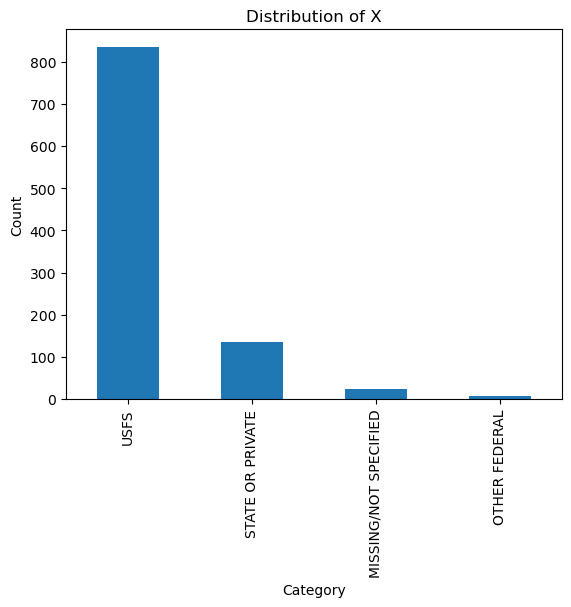

In [35]:
counts = df_small["OWNER_DESCR"].value_counts()

counts.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Distribution of X")
plt.show()